# Inferring network from single-cell data with CausFate

## Structure learning

### Load packages

In [1]:
suppressPackageStartupMessages({
    library(Seurat)
    library(foreach)
    library(dplyr)
    library(tidyr)
    library(bnlearn)
    library(Matrix)
    library(space)
    library(infotheo)
    library(igraph)
    library(graph)
    library(Rgraphviz)
    library(tibble)
})

library(causfate)

Setting plotting options for jupyter notebooks. These settings are not necessary when running the code in an R environment outside of jupyter notebooks.

In [2]:
options(repr.plot.format = "png", repr.plot.width = 5.5, repr.plot.height = 5.5)
options(jupyter.plot_mimetypes = "image/png")

### Load data

In [3]:
data("HMR")
head(HMR)

,orig.ident,nCount_RNA,nFeature_RNA,celltype,percent.mt,S.Score,G2M.Score,Phase,old.ident
,<fct>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<fct>,<fct>
HSPC_002,HSPC,1085.3333,8778,LTHSC,0,-0.12077291,-0.09083001,G1,HSPC
HSPC_004,HSPC,1221.0767,11352,LMPP,0,-0.16803616,-0.10391938,G1,HSPC
HSPC_006,HSPC,1431.2583,11891,LMPP,0,-0.01206173,-0.11841703,G1,HSPC
HSPC_008,HSPC,1514.3543,10355,LMPP,0,-0.16419568,-0.12593563,G1,HSPC
HSPC_011,HSPC,1516.5897,10977,LMPP,0,-0.19785059,-0.15114819,G1,HSPC
HSPC_014,HSPC,1470.6718,9533,MPP,0,-0.16047674,-0.13218429,G1,HSPC
HSPC_015,HSPC,800.7971,9825,LMPP,0,-0.10753757,-0.08138777,G1,HSPC
HSPC_017,HSPC,1386.0569,10124,LTHSC,0,-0.17785950,-0.12033867,G1,HSPC
HSPC_018,HSPC,1876.0635,11314,MPP,0,-0.18039289,-0.17387886,G1,HSPC


In [4]:
dim(HMR)

[1] 40198   716

### Find variable genes

Note that `gem2mem` is used to transform the single-cell data to cell type-specific gene profiles.

In [5]:
HMR <- FindVariableFeatures(HMR, selection.method = "vst", nfeatures = nrow(HMR))
glist <- VariableFeatures(HMR)

meta <- HMR@meta.data[["celltype"]] %>% setNames(colnames(HMR))
ctypes <- c("LTHSC", "MPP", "CMP", "LMPP", "MEP", "GMP")
pseudobulk_expmat <- gem2mem(data.frame(HMR@assays$RNA@data), meta, "mean")

Warning message:
"Command FindVariableFeatures.RNA changing from SeuratCommand to SeuratCommand"


### BMA process

`BNLearning` samples the data and performs the inner BMA process, giving out multiple one-shot DAGs. `combineDAGsmpl` combines those DAGs before pruning.

In [6]:
dag_smpl <- BNLearning(HMR[glist[1:5000]],
  resampling_fraction = 0.2, # Fraction of cells used in each resampled dataset
  N_smpl = 40, params = seq(0.05, 0.3, 0.05),
  root = "LTHSC", mode = "single_cell", ncores = 1,
  dagMethod = "hc", ugMethod = "cmi2ni", seed = 42
)
net <- combineDAGsmpl(dag_smpl, Emin = 1, Emax = 7, ncores = 1)

# Let us take a glimpse of the structure now
net_mat <- net %>% df2mat() %>% .[ctypes, ctypes]
net_mat

,LTHSC,MPP,CMP,LMPP,MEP,GMP
LTHSC,0,124,18,58,0,0
MPP,0,0,112,63,7,5
CMP,0,5,0,28,120,120
LMPP,0,61,21,0,0,6
MEP,0,0,0,0,0,0
GMP,0,0,4,0,0,0


First, very unlikely edges are trimmed if the occurrence is less than 2. Then, `rmCyc` removes cycles, preserving the more possible edges.

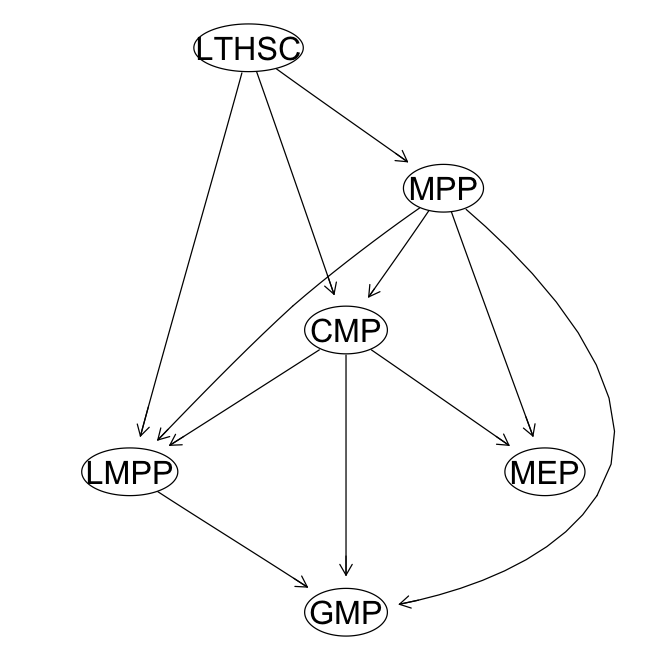

In [7]:
net <- (net_mat * (net_mat > 2)) %>%
  mat2df() %>%
  rmCyc()
e <- df2bn(net, ctypes, plot = TRUE)

`trimDAG` performs the final local pruning step.

In [8]:
dag_struc <- trimDAG(dat_tmp = pseudobulk_expmat[glist[1:4000], ], e = e, min_arc = 2, max_arc = 2, threshold_value = 1, plot = FALSE)

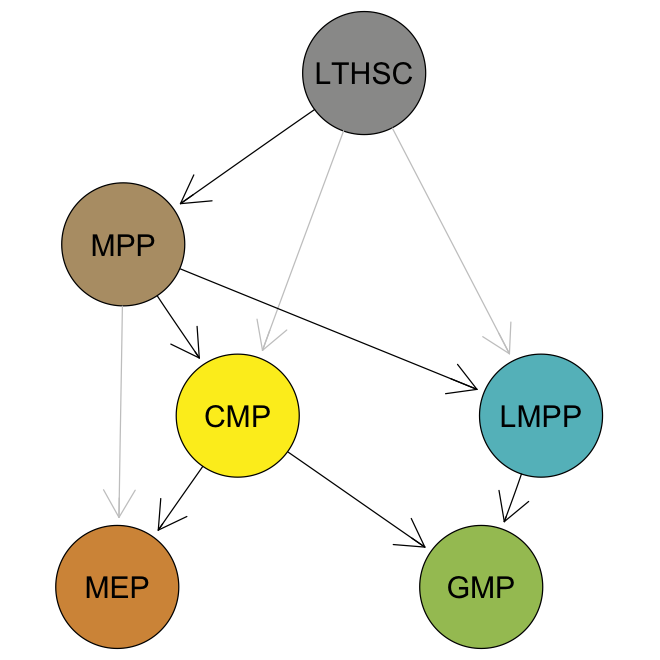

In [9]:
node_col <- c(
  "LTHSC" = "#9A9A99",
  "MPP" = "#B69D75",
  "CMP" = "#FCED21",
  "LMPP" = "#63BDC5",
  "MEP" = "#D59546",
  "GMP" = "#A4C362"
)
ref_net <- bnlearn::model2network("[LTHSC][MPP|LTHSC][CMP|MPP][LMPP|MPP][MEP|CMP][GMP|CMP:LMPP]")
colorEdges(dag_struc, ref_net, 
           node_col = node_col, 
           fontsize = 10, 
           node_size = 2,
           sep = 0.8)

## Calculate gene-wise causal effects

Generate indexes for bootstrapping.

In [10]:
set.seed(42)
index <- bootstrap_index(
  meta = meta,
  bootstrap_times = 10,
  resampling_fraction = 0.3 # Fraction of cells sampled from each cell state
)

Set `perturb_ratio` to 0 for zeroing, a value between 0 and 1 for knockdown, a value greater than 1 for knockup, or `"deletion"` for feature deletion. A value of 1 leaves the feature unchanged.

`EffectMatrix(..., dist_metric = 'diff_mean')` calculates signed mean-shift effects. `diffScore(abs = TRUE)` uses their absolute values when ranking features. Other available metrics are W1, W2, energy and mmd.

In [11]:
perturbRes <- PerturbResult(
  net_struc = dag_struc,
  data = HMR,
  meta = meta,
  index = index,
  n_sample = 10,
  mode = "single_cell", # Input data mode
  perturbation = "single_feature", # GRN-free perturbation
  perturb_ratio = 0, # 0: zeroing; 0 < ratio < 1: knockdown; >1: knockup; "deletion": feature deletion
  ncores = 5
)
effMat <- EffectMatrix(perturbRes, dist_metric = "diff_mean")

Score and rank genes with `diffScore` and `dsRank`. Here all edges are selected and overall effects to the network are calculated. A subset of edges can be chosen to study for specific differentiation processes.

In [12]:
edgeSet <- setEdges(fromSet = ctypes, toSet = ctypes) # Calculate for all edges
effectScore <- diffScore(effMat, edgeSet)
geneList <- dsRank(effectScore)
head(geneList)

[1] "Mpo"            "Ctsg"           "X..not.aligned" "Plac8"         
[5] "Apoe"           "Car1"